# Banjir TF IDF

**Nama:** Alisha Rafimalia  
**NRP:** 5026231202  
**Kelas:** PBA A  

# Import Dependencies

In [1]:
import math
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
nltk.download('punkt')
from sklearn.feature_extraction.text import TfidfVectorizer

import pandas as pd

[nltk_data] Downloading package punkt to /Users/sasharfml/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# Define Document

In [2]:
sentence = """
Banjir bandang di Masamba, Kabupaten Luwu Utara, Sulawesi Selatan, menjadi salah satu bencana besar yang mendapat sorotan luas karena menimbulkan korban jiwa dan kerusakan infrastruktur.

Peristiwa ini dipicu hujan berintensitas tinggi yang menyebabkan aliran sungai meluap dan membawa material lumpur, kayu, serta batu ke wilayah permukiman warga.

Dampak banjir meluas ke banyak titik, termasuk rumah tinggal, fasilitas umum, dan akses jalan yang sempat terputus sehingga proses evakuasi serta distribusi bantuan menjadi lebih sulit pada fase awal penanganan.

Dalam pemberitaan saat itu, jumlah korban meninggal dilaporkan mencapai belasan orang, sementara warga lainnya harus mengungsi dan menunggu proses pencarian serta pendataan lanjutan oleh petugas.

Tim gabungan dari pemerintah daerah, BPBD, TNI-Polri, tenaga kesehatan, dan relawan dikerahkan untuk evakuasi, pencarian korban, pendirian posko, hingga pemulihan layanan dasar bagi masyarakat terdampak.

Kejadian ini menegaskan pentingnya mitigasi bencana berbasis wilayah sungai, peringatan dini cuaca ekstrem, dan koordinasi lintas instansi agar risiko korban serta kerugian dapat ditekan ketika banjir besar terjadi kembali.
"""

# Text Preprocessing

In [3]:
import nltk
from nltk.tokenize import sent_tokenize

# Download the 'punkt_tab' data
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/sasharfml/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
# Sentence tokenization
sent_token = sent_tokenize(sentence)
print(sent_token)

['\nBanjir bandang di Masamba, Kabupaten Luwu Utara, Sulawesi Selatan, menjadi salah satu bencana besar yang mendapat sorotan luas karena menimbulkan korban jiwa dan kerusakan infrastruktur.', 'Peristiwa ini dipicu hujan berintensitas tinggi yang menyebabkan aliran sungai meluap dan membawa material lumpur, kayu, serta batu ke wilayah permukiman warga.', 'Dampak banjir meluas ke banyak titik, termasuk rumah tinggal, fasilitas umum, dan akses jalan yang sempat terputus sehingga proses evakuasi serta distribusi bantuan menjadi lebih sulit pada fase awal penanganan.', 'Dalam pemberitaan saat itu, jumlah korban meninggal dilaporkan mencapai belasan orang, sementara warga lainnya harus mengungsi dan menunggu proses pencarian serta pendataan lanjutan oleh petugas.', 'Tim gabungan dari pemerintah daerah, BPBD, TNI-Polri, tenaga kesehatan, dan relawan dikerahkan untuk evakuasi, pencarian korban, pendirian posko, hingga pemulihan layanan dasar bagi masyarakat terdampak.', 'Kejadian ini menegask

In [5]:
# Training TF-IDF Vectorizer on sentences
vectorizer = TfidfVectorizer(stop_words='english')
features = vectorizer.fit_transform(sent_token)

In [6]:
# Pastikan punkt tersedia (opsional jika hanya split manual)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

# Gunakan teks banjir dari Cell 5
sent_token = [line.strip() for line in sentence.split('\n') if line.strip()]

print("Tokenized sentences:")
for sent in sent_token:
    print(sent)

cleaned_sentences = sent_token
print("\nCleaned sentences:")
for clean_sent in cleaned_sentences:
    print(clean_sent)

# TF-IDF untuk teks Indonesia (tanpa stop_words='english')
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

print("\nTF-IDF Feature Matrix (Sparse):")
print(features)

print("\nShape of the Feature Matrix:")
print(features.shape)

feature_names = vectorizer.get_feature_names_out()
print("\nFeature Names:")
print(list(feature_names))

if cleaned_sentences:
    first_cleaned_sentence_tfidf = features[0].toarray()
    print("\nTF-IDF values for the first sentence:")
    print(first_cleaned_sentence_tfidf)

    def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
        """Mengembalikan DataFrame TF-IDF yang diurutkan."""
        sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
        tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
        tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
        return tfidf_df

    first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)
    print("\nTF-IDF values for the first sentence (sorted):")
    print(first_sentence_tfidf_df)
else:
    print("\nNo sentences to process.")

Tokenized sentences:
Banjir bandang di Masamba, Kabupaten Luwu Utara, Sulawesi Selatan, menjadi salah satu bencana besar yang mendapat sorotan luas karena menimbulkan korban jiwa dan kerusakan infrastruktur.
Peristiwa ini dipicu hujan berintensitas tinggi yang menyebabkan aliran sungai meluap dan membawa material lumpur, kayu, serta batu ke wilayah permukiman warga.
Dampak banjir meluas ke banyak titik, termasuk rumah tinggal, fasilitas umum, dan akses jalan yang sempat terputus sehingga proses evakuasi serta distribusi bantuan menjadi lebih sulit pada fase awal penanganan.
Dalam pemberitaan saat itu, jumlah korban meninggal dilaporkan mencapai belasan orang, sementara warga lainnya harus mengungsi dan menunggu proses pencarian serta pendataan lanjutan oleh petugas.
Tim gabungan dari pemerintah daerah, BPBD, TNI-Polri, tenaga kesehatan, dan relawan dikerahkan untuk evakuasi, pencarian korban, pendirian posko, hingga pemulihan layanan dasar bagi masyarakat terdampak.
Kejadian ini menega

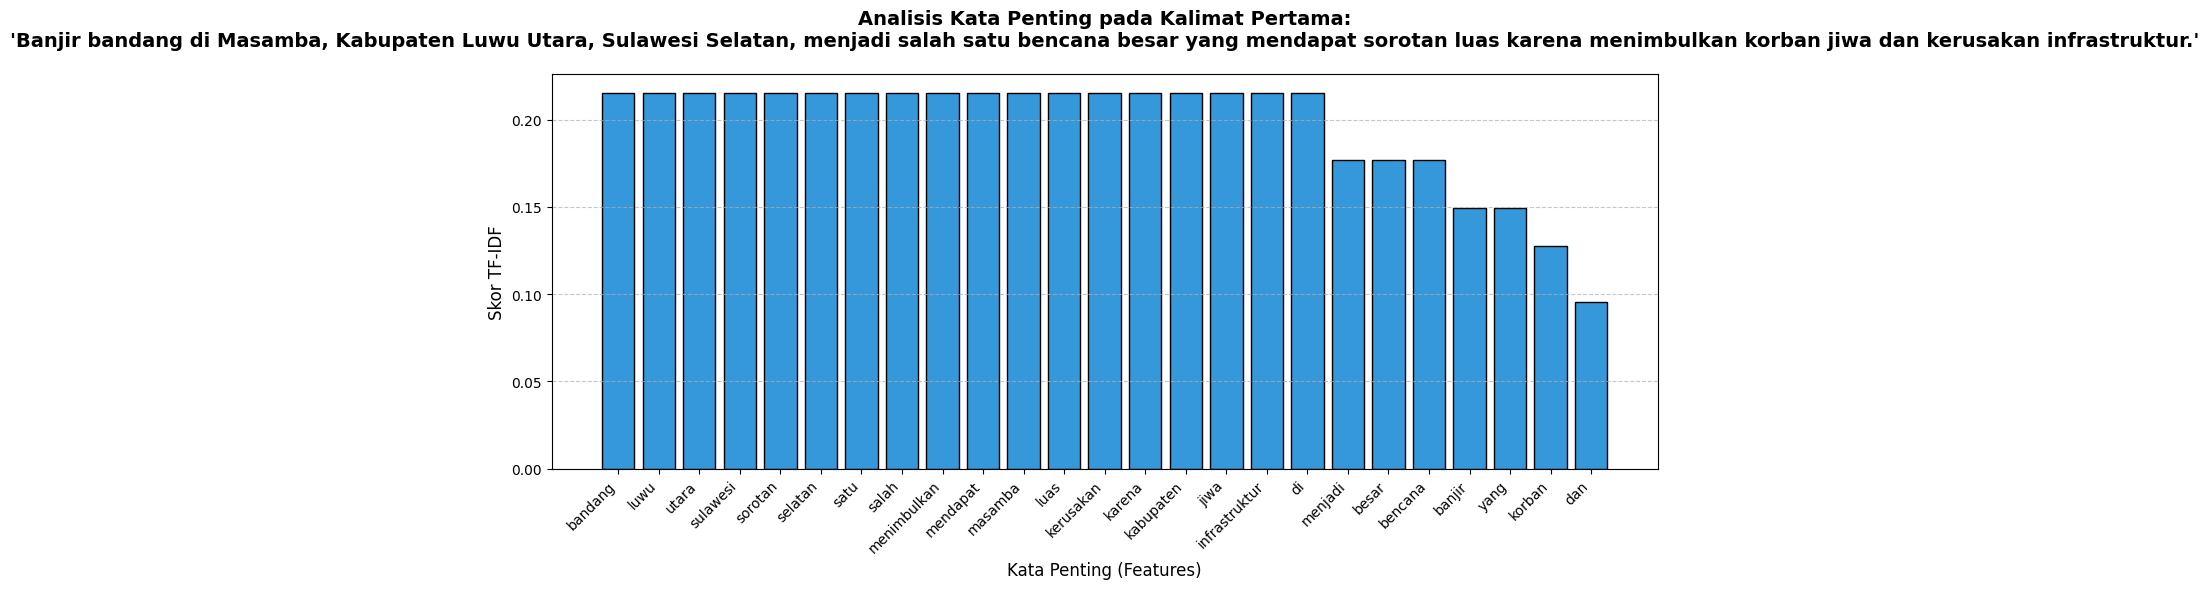


Tabel Nilai TF-IDF (Sorted):
           Feature    TF-IDF
5          bandang  0.215541
65            luwu  0.215541
127          utara  0.215541
112       sulawesi  0.215541
111        sorotan  0.215541
107        selatan  0.215541
105           satu  0.215541
104          salah  0.215541
76     menimbulkan  0.215541
73        mendapat  0.215541
66         masamba  0.215541
63            luas  0.215541
53       kerusakan  0.215541
47          karena  0.215541
46       kabupaten  0.215541
44            jiwa  0.215541
39   infrastruktur  0.215541
24              di  0.215541
78         menjadi  0.176747
14           besar  0.176747
11         bencana  0.176747
6           banjir  0.149222
130           yang  0.149222
57          korban  0.127872
20             dan  0.095678


In [7]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

# Gunakan teks banjir dari Cell 5
sent_token = [line.strip() for line in sentence.split('\n') if line.strip()]
cleaned_sentences = sent_token

vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)
feature_names = vectorizer.get_feature_names_out()

def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
    """Menghasilkan DataFrame bobot kata untuk kalimat tertentu."""
    sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
    tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
    tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
    return tfidf_df

if cleaned_sentences:
    first_sentence = cleaned_sentences[0]
    df_plot = get_tfidf_for_sentence(features, 0, feature_names)

    plt.figure(figsize=(12, 6))
    plt.bar(df_plot['Feature'], df_plot['TF-IDF'], color='#3498db', edgecolor='black')

    plt.xlabel("Kata Penting (Features)", fontsize=12)
    plt.ylabel("Skor TF-IDF", fontsize=12)
    plt.title(f"Analisis Kata Penting pada Kalimat Pertama:\n'{first_sentence}'", fontsize=14, fontweight='bold', pad=20)

    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print("\nTabel Nilai TF-IDF (Sorted):")
    print(df_plot)
else:
    print("Tidak ada kalimat untuk divisualisasikan.")

# Calculate Sentence Score

**List of Sentences:**
1. Banjir bandang di Masamba, Kabupaten Luwu Utara, Sulawesi Selatan, menjadi salah satu bencana besar yang mendapat sorotan luas karena menimbulkan korban jiwa dan kerusakan infrastruktur.
2. Peristiwa ini dipicu hujan berintensitas tinggi yang menyebabkan aliran sungai meluap dan membawa material lumpur, kayu, serta batu ke wilayah permukiman warga.
3. Dampak banjir meluas ke banyak titik, termasuk rumah tinggal, fasilitas umum, dan akses jalan yang sempat terputus sehingga proses evakuasi serta distribusi bantuan menjadi lebih sulit pada fase awal penanganan.
4. Dalam pemberitaan saat itu, jumlah korban meninggal dilaporkan mencapai belasan orang, sementara warga lainnya harus mengungsi dan menunggu proses pencarian serta pendataan lanjutan oleh petugas.
5. Tim gabungan dari pemerintah daerah, BPBD, TNI-Polri, tenaga kesehatan, dan relawan dikerahkan untuk evakuasi, pencarian korban, pendirian posko, hingga pemulihan layanan dasar bagi masyarakat terdampak.
6.

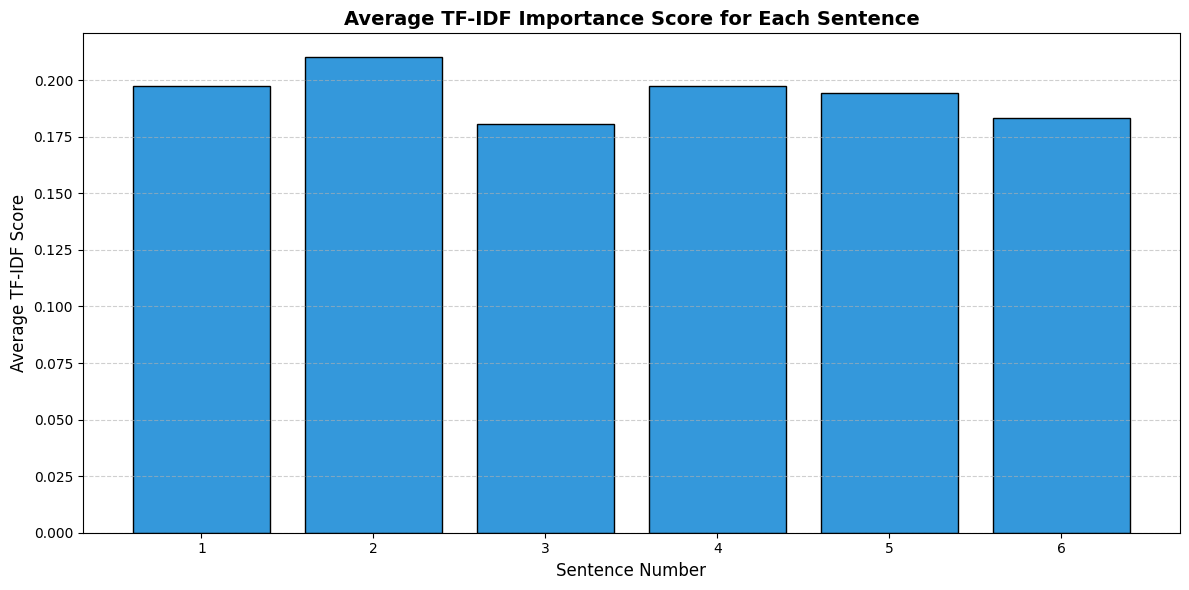

In [8]:
sentence2 = sentence

# Tokenisasi kalimat manual sesuai baris
sent_token2 = [line.strip() for line in sentence2.split('\n') if line.strip()]

# Inisialisasi TF-IDF untuk teks Indonesia
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(sent_token2)

sent_scores = []

print("**List of Sentences:**")
for i, sent in enumerate(sent_token2):
    print(f"{i + 1}. {sent}")
print("\n" + "-"*30)

print("\n**Average TF-IDF Score for Each Sentence:**")
for i, row in enumerate(features):
    sent_score = row.sum()
    sent_length = row.nnz

    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores.append(avg_score)

    print(f"- Sentence {i + 1}")
    print(f"   Sum of TF-IDF scores: {sent_score:.4f}")
    print(f"   Number of important words: {sent_length}")
    print(f"   Average TF-IDF score: {avg_score:.4f}")

print("\n" + "-"*30)
print("\nList of average TF-IDF scores for each sentence:")
print([round(score, 4) for score in sent_scores])

plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sent_scores) + 1), sent_scores, color='#3498db', edgecolor='black')
plt.xlabel("Sentence Number", fontsize=12)
plt.ylabel("Average TF-IDF Score", fontsize=12)
plt.title("Average TF-IDF Importance Score for Each Sentence", fontsize=14, fontweight='bold')
plt.xticks(range(1, len(sent_scores) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Define Threshold

In [9]:
sentence_banjir = sentence

sent_token2 = sent_tokenize(sentence_banjir)

# TF-IDF untuk teks Indonesia
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(sent_token2)

sent_scores = []

print("--- Perhitungan Skor TF-IDF Per Kalimat ---")
for i, row in enumerate(features):
    sent_score = row.sum()
    sent_length = row.nnz
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores.append(avg_score)
    print(f"Sentence {i + 1}: Score = {avg_score:.4f}")

threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0
print(f"\nThreshold (Average of Sentence Scores): {threshold:.4f}")

--- Perhitungan Skor TF-IDF Per Kalimat ---
Sentence 1: Score = 0.1973
Sentence 2: Score = 0.2102
Sentence 3: Score = 0.1804
Sentence 4: Score = 0.1973
Sentence 5: Score = 0.1942
Sentence 6: Score = 0.1832

Threshold (Average of Sentence Scores): 0.1937


In [10]:
sentence_text = sentence

# Tokenisasi kalimat
sentences = [s.strip() for s in sent_tokenize(sentence_text) if s.strip()]
all_cleaned_sentences = sentences

def calculate_tf(term, document):
    """TF = jumlah kemunculan kata pada kalimat / total kata kalimat."""
    words = word_tokenize(document.lower())
    return words.count(term.lower()) / len(words) if len(words) > 0 else 0

def calculate_idf(term, all_documents):
    """IDF = log(total kalimat / jumlah kalimat yang mengandung kata)."""
    num_documents_with_term = sum(
        1 for doc in all_documents if term.lower() in word_tokenize(doc.lower())
    )
    if num_documents_with_term > 0:
        return math.log(len(all_documents) / num_documents_with_term)
    return 0

target_word = "banjir"
tfidf_scores = {}
overall_idf = calculate_idf(target_word, all_cleaned_sentences)

for i, sent in enumerate(sentences):
    tf = calculate_tf(target_word, sent)
    tfidf = tf * overall_idf
    tfidf_scores[f"Sentence {i+1}"] = tfidf

print(f"--- ANALISIS TF-IDF MANUAL (Target: '{target_word}') ---")
print(f"Total Kalimat (N) : {len(sentences)}")
print(f"Overall IDF       : {overall_idf:.4f}\n")

print("TF-IDF Score for each sentence:")
for sentence_num, score in tfidf_scores.items():
    if score > 0:
        print(f"{sentence_num}: {score:.4f}")

best_sentence = max(tfidf_scores, key=tfidf_scores.get)
print(f"\nKalimat paling relevan untuk kata '{target_word}': {best_sentence}")

--- ANALISIS TF-IDF MANUAL (Target: 'banjir') ---
Total Kalimat (N) : 6
Overall IDF       : 0.6931

TF-IDF Score for each sentence:
Sentence 1: 0.0239
Sentence 3: 0.0204
Sentence 6: 0.0217

Kalimat paling relevan untuk kata 'banjir': Sentence 1


# Get Sentences

In [11]:
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
import math

sentence_banjir = sentence

sent_token = sent_tokenize(sentence_banjir)

vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(sent_token)

sent_scores = []

for row in features:
    sent_score = row.sum()
    sent_length = row.nnz
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores.append(avg_score)

threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0
print(f"Threshold (Average of Sentence Scores): {threshold:.4f}")

final_summ = ""

print("\nSummary Sentences (above or equal to the threshold):")
for index, score in enumerate(sent_scores):
    if score >= threshold:
        final_summ = final_summ + " " + sent_token[index]
        print(f"- {sent_token[index]}")

print("\nFinal Summary:")
print(final_summ.strip())

Threshold (Average of Sentence Scores): 0.1937

Summary Sentences (above or equal to the threshold):
- 
Banjir bandang di Masamba, Kabupaten Luwu Utara, Sulawesi Selatan, menjadi salah satu bencana besar yang mendapat sorotan luas karena menimbulkan korban jiwa dan kerusakan infrastruktur.
- Peristiwa ini dipicu hujan berintensitas tinggi yang menyebabkan aliran sungai meluap dan membawa material lumpur, kayu, serta batu ke wilayah permukiman warga.
- Dalam pemberitaan saat itu, jumlah korban meninggal dilaporkan mencapai belasan orang, sementara warga lainnya harus mengungsi dan menunggu proses pencarian serta pendataan lanjutan oleh petugas.
- Tim gabungan dari pemerintah daerah, BPBD, TNI-Polri, tenaga kesehatan, dan relawan dikerahkan untuk evakuasi, pencarian korban, pendirian posko, hingga pemulihan layanan dasar bagi masyarakat terdampak.

Final Summary:
Banjir bandang di Masamba, Kabupaten Luwu Utara, Sulawesi Selatan, menjadi salah satu bencana besar yang mendapat sorotan luas

In [12]:
sentence_text = sentence

# TOKENISASI MANUAL
sentences = [line.strip() for line in sentence_text.split('\n') if line.strip()]

def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term.lower()) / len(words) if len(words) > 0 else 0

def calculate_idf(term, all_documents):
    num_docs_with_term = sum(1 for doc in all_documents if term.lower() in word_tokenize(doc.lower()))
    if num_docs_with_term > 0:
        return math.log(len(all_documents) / num_docs_with_term)
    return 0

target = "banjir"
overall_idf = calculate_idf(target, sentences)

print(f"TF-IDF Score for '{target}' in each sentence:")
for i, sent in enumerate(sentences):
    tf = calculate_tf(target, sent)
    score = tf * overall_idf
    print(f"Sentence {i+1}: {score:.4f}")

print(f"\nOverall IDF for '{target}': {overall_idf:.4f}")

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(sentences)
feature_names = list(vectorizer.get_feature_names_out())

print(f"\nTF-IDF Score for '{target}' using TfidfVectorizer:")
try:
    target_idx = feature_names.index(target)
    for i in range(len(sentences)):
        tfidf_val = tfidf_matrix[i, target_idx]
        print(f"Sentence {i+1}: {tfidf_val:.4f}")
except ValueError:
    print(f"Target word '{target}' not found in vocabulary.")

TF-IDF Score for 'banjir' in each sentence:
Sentence 1: 0.0239
Sentence 2: 0.0000
Sentence 3: 0.0204
Sentence 4: 0.0000
Sentence 5: 0.0000
Sentence 6: 0.0217

Overall IDF for 'banjir': 0.6931

TF-IDF Score for 'banjir' using TfidfVectorizer:
Sentence 1: 0.1492
Sentence 2: 0.0000
Sentence 3: 0.1353
Sentence 4: 0.0000
Sentence 5: 0.0000
Sentence 6: 0.1392


In [13]:
final_summ

' \nBanjir bandang di Masamba, Kabupaten Luwu Utara, Sulawesi Selatan, menjadi salah satu bencana besar yang mendapat sorotan luas karena menimbulkan korban jiwa dan kerusakan infrastruktur. Peristiwa ini dipicu hujan berintensitas tinggi yang menyebabkan aliran sungai meluap dan membawa material lumpur, kayu, serta batu ke wilayah permukiman warga. Dalam pemberitaan saat itu, jumlah korban meninggal dilaporkan mencapai belasan orang, sementara warga lainnya harus mengungsi dan menunggu proses pencarian serta pendataan lanjutan oleh petugas. Tim gabungan dari pemerintah daerah, BPBD, TNI-Polri, tenaga kesehatan, dan relawan dikerahkan untuk evakuasi, pencarian korban, pendirian posko, hingga pemulihan layanan dasar bagi masyarakat terdampak.'

In [14]:
# Final summary initialization
final_summ = ""

# Get summary sentences
for index, data in enumerate(sent_scores) :
  if (data >= (threshold)) :
    final_summ = final_summ + " " + sent_token[index]
    print("- ", sent_token[index])

-  
Banjir bandang di Masamba, Kabupaten Luwu Utara, Sulawesi Selatan, menjadi salah satu bencana besar yang mendapat sorotan luas karena menimbulkan korban jiwa dan kerusakan infrastruktur.
-  Peristiwa ini dipicu hujan berintensitas tinggi yang menyebabkan aliran sungai meluap dan membawa material lumpur, kayu, serta batu ke wilayah permukiman warga.
-  Dalam pemberitaan saat itu, jumlah korban meninggal dilaporkan mencapai belasan orang, sementara warga lainnya harus mengungsi dan menunggu proses pencarian serta pendataan lanjutan oleh petugas.
-  Tim gabungan dari pemerintah daerah, BPBD, TNI-Polri, tenaga kesehatan, dan relawan dikerahkan untuk evakuasi, pencarian korban, pendirian posko, hingga pemulihan layanan dasar bagi masyarakat terdampak.


# Summarization Result

In [15]:
final_summ

' \nBanjir bandang di Masamba, Kabupaten Luwu Utara, Sulawesi Selatan, menjadi salah satu bencana besar yang mendapat sorotan luas karena menimbulkan korban jiwa dan kerusakan infrastruktur. Peristiwa ini dipicu hujan berintensitas tinggi yang menyebabkan aliran sungai meluap dan membawa material lumpur, kayu, serta batu ke wilayah permukiman warga. Dalam pemberitaan saat itu, jumlah korban meninggal dilaporkan mencapai belasan orang, sementara warga lainnya harus mengungsi dan menunggu proses pencarian serta pendataan lanjutan oleh petugas. Tim gabungan dari pemerintah daerah, BPBD, TNI-Polri, tenaga kesehatan, dan relawan dikerahkan untuk evakuasi, pencarian korban, pendirian posko, hingga pemulihan layanan dasar bagi masyarakat terdampak.'